In [24]:
#Khai bao
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import statsmodels.api as sm
import numpy as np
from sklearn.metrics import roc_curve, auc

In [2]:
# 1. Đọc dữ liệu
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
data = pd.read_csv('pima-indians-diabetes.data.csv', header=None, names=column_names)


In [3]:
# Tiền xử lý: Lọc bỏ giá trị 0 ở Glucose và BMI để phân cụm chính xác hơn
data_clean = data[(data['Glucose'] > 0) & (data['BMI'] > 0)].copy()

# 2. Lấy dữ liệu cần phân cụm
X_cluster = data_clean[['Glucose', 'BMI']]

# 3. Thực hiện thuật toán K-Means với k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
data_clean['Cum'] = kmeans.fit_predict(X_cluster)

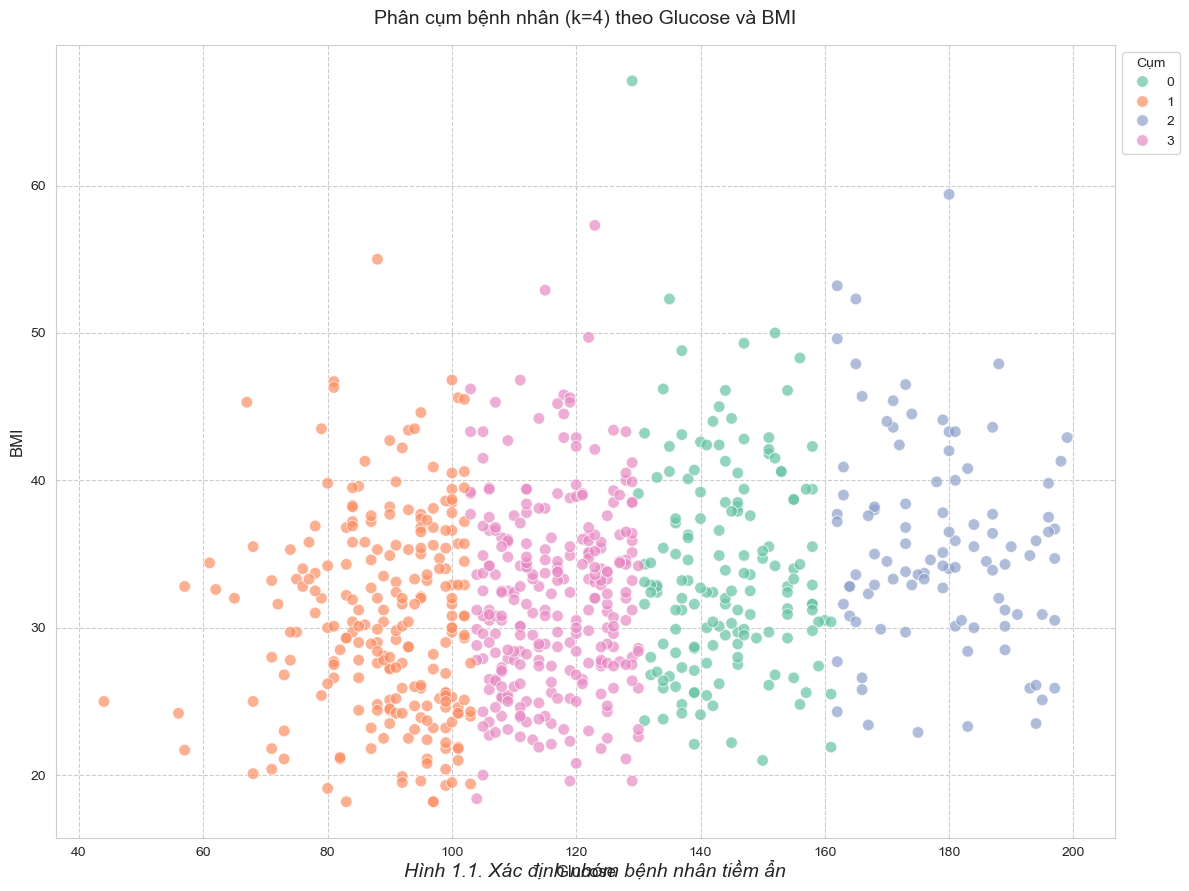

In [4]:
# 4. Cấu hình giao diện vẽ hình
plt.figure(figsize=(12, 9))
sns.set_style("whitegrid", {'axes.grid' : True, 'grid.linestyle': '--', 'grid.alpha': 0.5})

# 5. Vẽ biểu đồ Scatter Plot theo các cụm (Cụm 0, 1, 2, 3)
# palette='Set2' cung cấp các màu pastel dịu nhẹ tương tự hình mẫu
sns.scatterplot(data=data_clean, 
                x='Glucose', 
                y='BMI', 
                hue='Cum', 
                palette='Set2', 
                s=70, 
                alpha=0.7, 
                edgecolor='w')

# 6. Tùy chỉnh tiêu đề và nhãn
plt.title('Phân cụm bệnh nhân (k=4) theo Glucose và BMI', fontsize=14, pad=15)
plt.xlabel('Glucose', fontsize=12)
plt.ylabel('BMI', fontsize=12)

# Thêm chú thích hình bên dưới
plt.figtext(0.5, 0.02, 'Hình 1.1. Xác định nhóm bệnh nhân tiềm ẩn', 
            ha='center', fontsize=14, style='italic')

plt.legend(title='Cụm', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [5]:
data_clean = data[(data['Glucose'] > 0) & (data['BMI'] > 0)].copy()

# 2. Phân cụm (đảm bảo đồng nhất với Hình 1.1 trước đó)
X_cluster = data_clean[['Glucose', 'BMI']]
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
data_clean['Cum'] = kmeans.fit_predict(X_cluster)

In [6]:
# 3. Tính toán thống kê cho từng cụm
summary_list = []
total_patients = len(data_clean)

for i in range(4):
    cluster_data = data_clean[data_clean['Cum'] == i]
    count = len(cluster_data)
    percentage = (count / total_patients) * 100
    
    # Tính Mean và Std cho các biến
    age_m, age_s = cluster_data['Age'].mean(), cluster_data['Age'].std()
    bmi_m, bmi_s = cluster_data['BMI'].mean(), cluster_data['BMI'].std()
    glu_m, glu_s = cluster_data['Glucose'].mean(), cluster_data['Glucose'].std()
    outcome_rate = cluster_data['Outcome'].mean() * 100
    
    print(f"CỤM {i}.0 ({count} bệnh nhân - {percentage:.1f}%):")
    print(f"* Tuổi trung bình: {age_m:.1f} ± {age_s:.1f}")
    print(f"* BMI trung bình: {bmi_m:.1f} ± {bmi_s:.1f}")
    print(f"* Glucose trung bình: {glu_m:.1f} ± {glu_s:.1f}")
    print(f"* Tỷ lệ mắc bệnh: {outcome_rate:.1f}%")
    print("-" * 30)

CỤM 0.0 (154 bệnh nhân - 20.5%):
* Tuổi trung bình: 37.2 ± 13.5
* BMI trung bình: 33.9 ± 7.1
* Glucose trung bình: 144.1 ± 8.5
* Tỷ lệ mắc bệnh: 51.9%
------------------------------
CỤM 1.0 (230 bệnh nhân - 30.6%):
* Tuổi trung bình: 29.5 ± 9.4
* BMI trung bình: 30.6 ± 6.7
* Glucose trung bình: 89.6 ± 10.5
* Tỷ lệ mắc bệnh: 10.0%
------------------------------
CỤM 2.0 (98 bệnh nhân - 13.0%):
* Tuổi trung bình: 38.3 ± 12.4
* BMI trung bình: 35.7 ± 7.0
* Glucose trung bình: 178.4 ± 11.1
* Tỷ lệ mắc bệnh: 82.7%
------------------------------
CỤM 3.0 (270 bệnh nhân - 35.9%):
* Tuổi trung bình: 32.5 ± 10.8
* BMI trung bình: 32.0 ± 6.4
* Glucose trung bình: 116.4 ± 8.0
* Tỷ lệ mắc bệnh: 29.6%
------------------------------


In [7]:
# Thực hiện phân cụm k=4 dựa trên Glucose và BMI
X_cluster = data_clean[['Glucose', 'BMI']]
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
data_clean['Cum'] = kmeans.fit_predict(X_cluster)


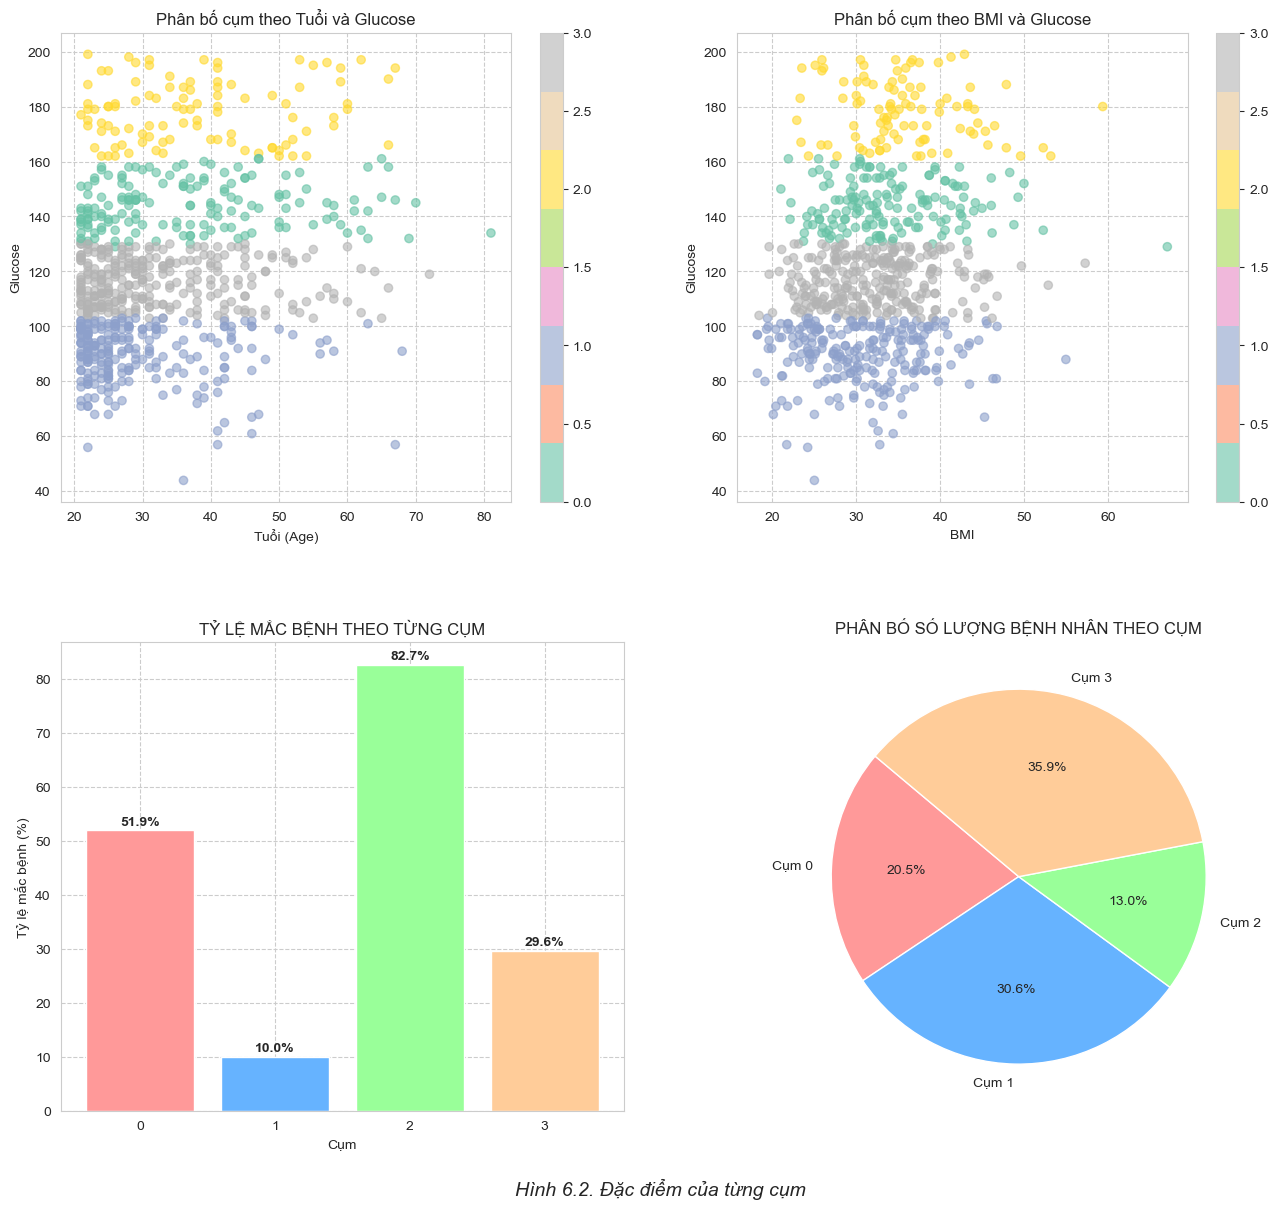

In [9]:
# 2. Khởi tạo Figure 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

# Định nghĩa bảng màu Pastel tương đồng hình mẫu
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']

# --- BIỂU ĐỒ 1: PHÂN BỐ CỤM THEO TUỔI VÀ GLUCOSE (Scatter) ---
scatter1 = axes[0, 0].scatter(data_clean['Age'], data_clean['Glucose'], 
                               c=data_clean['Cum'], cmap='Set2', alpha=0.6)
axes[0, 0].set_title('Phân bố cụm theo Tuổi và Glucose')
axes[0, 0].set_xlabel('Tuổi (Age)')
axes[0, 0].set_ylabel('Glucose')
fig.colorbar(scatter1, ax=axes[0, 0])

# --- BIỂU ĐỒ 2: PHÂN BỐ CỤM THEO BMI VÀ GLUCOSE (Scatter) ---
scatter2 = axes[0, 1].scatter(data_clean['BMI'], data_clean['Glucose'], 
                               c=data_clean['Cum'], cmap='Set2', alpha=0.6)
axes[0, 1].set_title('Phân bố cụm theo BMI và Glucose')
axes[0, 1].set_xlabel('BMI')
axes[0, 1].set_ylabel('Glucose')
fig.colorbar(scatter2, ax=axes[0, 1])

# --- BIỂU ĐỒ 3: TỶ LỆ MẮC BỆNH THEO TỪNG CỤM (Bar Chart) ---
outcome_rates = data_clean.groupby('Cum')['Outcome'].mean() * 100
bars = axes[1, 0].bar(outcome_rates.index.astype(str), outcome_rates.values, color=colors)
axes[1, 0].set_title('TỶ LỆ MẮC BỆNH THEO TỪNG CỤM')
axes[1, 0].set_ylabel('Tỷ lệ mắc bệnh (%)')
axes[1, 0].set_xlabel('Cụm')
for bar in bars:
    yval = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', fontweight='bold')

# --- BIỂU ĐỒ 4: PHÂN BỐ SỐ LƯỢNG BỆNH NHÂN (Pie Chart) ---
cluster_counts = data_clean['Cum'].value_counts().sort_index()
axes[1, 1].pie(cluster_counts, labels=[f'Cụm {i}' for i in range(4)], 
                autopct='%1.1f%%', colors=colors, startangle=140)
axes[1, 1].set_title('PHÂN BỐ SỐ LƯỢNG BỆNH NHÂN THEO CỤM')

# Chú thích tổng quát
plt.figtext(0.5, 0.05, 'Hình 6.2. Đặc điểm của từng cụm', 
            ha='center', fontsize=14, style='italic')

plt.show()

In [17]:
# 2. Định nghĩa các ngưỡng (Thresholds) dựa trên ảnh mẫu
thresholds = {
    'Glucose': 126.0,
    'BMI': 35.0,
    'Age': 45.0,
    'Pregnancies': 4.0,
    'DiabetesPedigreeFunction': 0.5,
    'BloodPressure': 90.0,
    'Insulin': 166.0,
    'SkinThickness': 30.0
}

# 3. Tạo biến giả (Dummy variables) dựa trên ngưỡng
data_binary = pd.DataFrame()
for col, threshold in thresholds.items():
    data_binary[col] = (data[col] >= threshold).astype(int)

data_binary['Outcome'] = data['Outcome']

# 4. Tính toán OR bằng Logistic Regression cho từng yếu tố (Univariate)
results = []
for col in thresholds.keys():
    X = sm.add_constant(data_binary[col])
    model = sm.Logit(data_binary['Outcome'], X).fit(disp=0)
    
    # OR = exp(coefficient)
    or_val = np.exp(model.params[col])
    conf = np.exp(model.conf_int().loc[col])
    p_val = model.pvalues[col]
    
    # Phân loại dựa trên giá trị OR
    classification = "Rất cao" if or_val > 4 else "Vừa" if or_val > 2 else "Thấp"
    
    results.append({
        'Yếu tố nguy cơ': col,
        'Ngưỡng >= ': thresholds[col],
        'OR': round(or_val, 2),
        '95% CI': f"({conf[0]:.2f}-{conf[1]:.2f})",
        'P-value': round(p_val, 3),
        'Phân loại': classification
    })

In [18]:
# 5. Hiển thị bảng kết quả
df_or = pd.DataFrame(results)
print("Bảng tỷ số chênh Odds Ratio")
print(df_or.to_string(index=False))

Bảng tỷ số chênh Odds Ratio
          Yếu tố nguy cơ  Ngưỡng >=    OR      95% CI  P-value Phân loại
                 Glucose       126.0 5.99 (4.33-8.29)    0.000   Rất cao
                     BMI        35.0 2.24 (1.64-3.06)    0.000       Vừa
                     Age        45.0 2.11 (1.45-3.08)    0.000       Vừa
             Pregnancies         4.0 2.26 (1.67-3.05)    0.000       Vừa
DiabetesPedigreeFunction         0.5 2.05 (1.51-2.79)    0.000       Vừa
           BloodPressure        90.0 1.84 (1.08-3.12)    0.025      Thấp
                 Insulin       166.0 2.36 (1.62-3.45)    0.000       Vừa
           SkinThickness        30.0 1.84 (1.35-2.51)    0.000      Thấp


In [19]:
data_points = {
    'Yếu tố nguy cơ': ['Glucose', 'BMI', 'Age', 'Pregnancies', 'DiabetesPedigreeFunction', 
                       'BloodPressure', 'Insulin', 'SkinThickness'],
    'Ngưỡng >= ': [126.0, 35.0, 45.0, 4.0, 0.5, 90.0, 166.0, 30.0],
    'OR': [5.79, 2.10, 2.22, 2.26, 2.14, 1.81, 2.46, 1.87],
    '95% CI': ['(4.14-8.10)', '(1.52-2.89)', '(1.51-3.27)', '(1.65-3.10)', 
               '(1.56-2.94)', '(1.06-3.09)', '(1.68-3.60)', '(1.36-2.57)']
}

df_scoring = pd.DataFrame(data_points)

# 2. Logic gán điểm dựa trên phân loại OR
# Rất cao (OR > 4) -> 4 điểm
# Vừa (OR > 2) -> 2 điểm
# Thấp (OR <= 2) -> 1 điểm
def assign_points(or_val):
    if or_val > 4: return 4
    elif or_val > 2: return 2
    else: return 1

def classify_risk(or_val):
    if or_val > 4: return "Rất cao"
    elif or_val > 2: return "Vừa"
    else: return "Thấp"

df_scoring['Phân loại'] = df_scoring['OR'].apply(classify_risk)
df_scoring['Điểm'] = df_scoring['OR'].apply(assign_points)

In [20]:
# 3. Hiển thị bảng
print("Bảng thang điểm nguy cơ")
print(df_scoring.to_string(index=False))

Bảng thang điểm nguy cơ
          Yếu tố nguy cơ  Ngưỡng >=    OR      95% CI Phân loại  Điểm
                 Glucose       126.0 5.79 (4.14-8.10)   Rất cao     4
                     BMI        35.0 2.10 (1.52-2.89)       Vừa     2
                     Age        45.0 2.22 (1.51-3.27)       Vừa     2
             Pregnancies         4.0 2.26 (1.65-3.10)       Vừa     2
DiabetesPedigreeFunction         0.5 2.14 (1.56-2.94)       Vừa     2
           BloodPressure        90.0 1.81 (1.06-3.09)      Thấp     1
                 Insulin       166.0 2.46 (1.68-3.60)       Vừa     2
           SkinThickness        30.0 1.87 (1.36-2.57)      Thấp     1


In [21]:
# 2. Định nghĩa từ điển điểm số (Scoring Dictionary) từ Bảng 6.3
scoring_rules = {
    'Glucose': (126.0, 4),
    'BMI': (35.0, 2),
    'Age': (45.0, 2),
    'Pregnancies': (4.0, 2),
    'Insulin': (166.0, 2),
    'DiabetesPedigreeFunction': (0.5, 2),
    'BloodPressure': (90.0, 1),
    'SkinThickness': (30.0, 1)
}

# 3. Hàm tính tổng điểm cho mỗi bệnh nhân
def calculate_total_score(row):
    score = 0
    for col, (threshold, points) in scoring_rules.items():
        if row[col] >= threshold:
            score += points
    return score

data['TotalScore'] = data.apply(calculate_total_score, axis=1)

# 4. Hàm phân loại tầng nguy cơ (Risk Levels)
def categorize_risk(score):
    if score >= 10: return 'Nguy cơ rất cao (≥10)'
    elif score >= 7: return 'Nguy cơ cao (7-9)'
    elif score >= 4: return 'Nguy cơ vừa (4-6)'
    else: return 'Nguy cơ thấp (0-3)'

data['RiskLevel'] = data['TotalScore'].apply(categorize_risk)

# 5. Thống kê kết quả
risk_summary = data.groupby('RiskLevel').agg(
    Tilệ_mắc_bệnh= ('Outcome', lambda x: round(x.mean() * 100, 1)),
    Số_BN= ('Outcome', 'count')
).reset_index()


In [22]:
#Sắp xếp theo mức độ nguy cơ từ thấp đến rất cao (tùy chọn)
print("Bảng phân loại nguy cơ bệnh")
print(risk_summary.to_string(index=False))

Bảng phân loại nguy cơ bệnh
            RiskLevel  Tilệ_mắc_bệnh  Số_BN
    Nguy cơ cao (7-9)           60.9    161
Nguy cơ rất cao (≥10)           67.0     91
   Nguy cơ thấp (0-3)           12.8    312
    Nguy cơ vừa (4-6)           33.8    204


In [25]:
features_to_eval = ['Glucose', 'BMI', 'Age', 'TotalScore'] # TotalScore chính là RiskScore

results = []

for feature in features_to_eval:
    # Tính toán FPR, TPR và các ngưỡng
    fpr, tpr, thresholds = roc_curve(data['Outcome'], data[feature])
    roc_auc = auc(fpr, tpr)
    
    # Tìm ngưỡng tối ưu bằng chỉ số Youden: J = Sensitivity + Specificity - 1
    # Tương đương với việc tìm Max(tpr - fpr)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    
    sensitivity = tpr[optimal_idx]
    specificity = 1 - fpr[optimal_idx]
    
    results.append({
        'Biến': 'RiskScore' if feature == 'TotalScore' else feature,
        'Ngưỡng tối ưu': round(optimal_threshold, 1),
        'AUC': round(roc_auc, 2),
        'Độ nhạy': f"{sensitivity*100:.1f}%",
        'Độ đặc hiệu': f"{specificity*100:.1f}%"
    })


In [26]:
# 3. Hiển thị bảng kết quả
df_roc = pd.DataFrame(results)
print("Bảng 6.5. Bảng ROC cho các biến")
print(df_roc.to_string(index=False))

Bảng 6.5. Bảng ROC cho các biến
     Biến  Ngưỡng tối ưu  AUC Độ nhạy Độ đặc hiệu
  Glucose          124.0 0.79   70.1%       73.2%
      BMI           29.9 0.69   82.5%       48.8%
      Age           29.0 0.69   73.5%       59.2%
RiskScore            6.0 0.77   68.3%       72.8%


In [29]:
# 1. Chuẩn bị dữ liệu (Dựa trên kết quả Bảng 6.6)
data_metrics = {
    'Threshold': [100, 110, 120, 130, 140, 150, 160],
    'Sensitivity': [94.8, 83.9, 74.2, 60.9, 51.6, 41.5, 32.7],
    'Specificity': [35.2, 53.2, 66.1, 79.9, 86.9, 92.2, 96.2],
    'Accuracy': [55.7, 63.7, 68.9, 73.3, 74.7, 74.7, 74.3]
}
df_plot = pd.DataFrame(data_metrics)



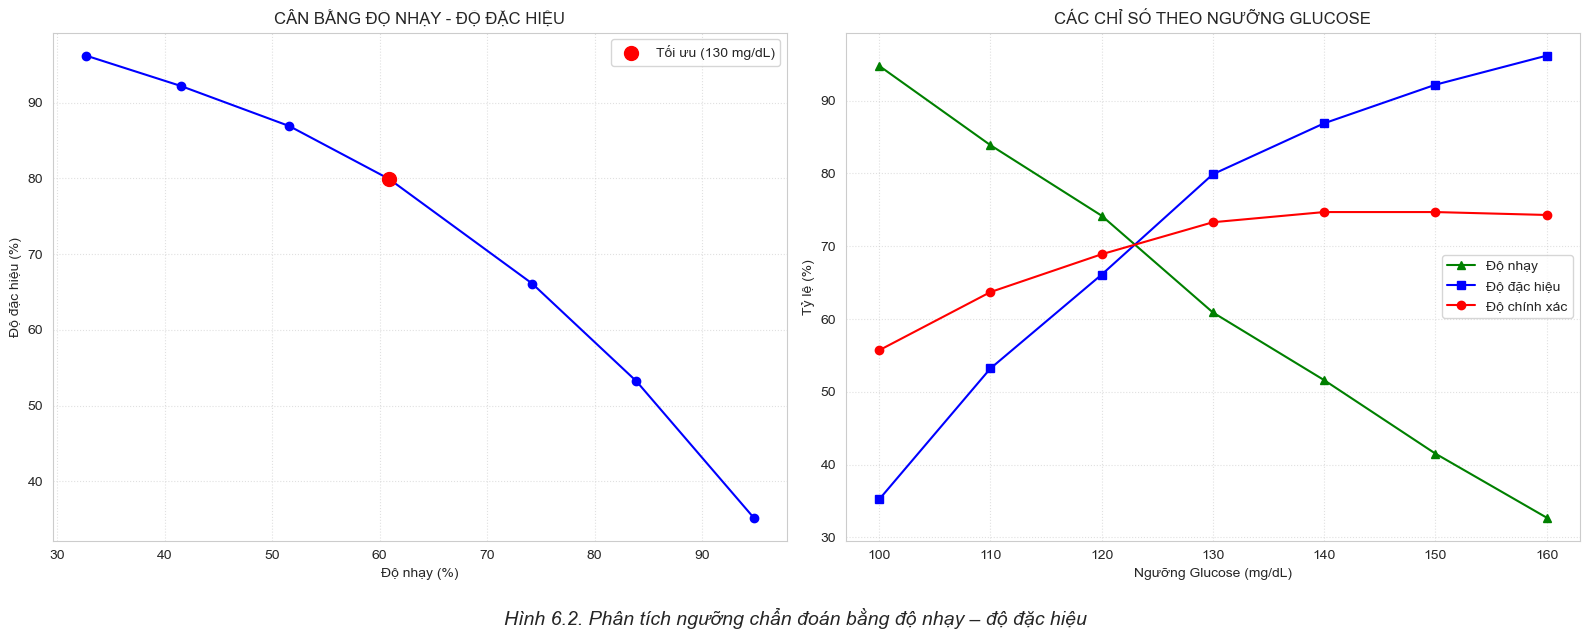

In [30]:
# 2. Khởi tạo Figure với 1 hàng và 2 cột
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- BIỂU ĐỒ TRÁI: CÂN BẰNG ĐỘ NHẠY - ĐỘ ĐẶC HIỆU ---
ax1.plot(df_plot['Sensitivity'], df_plot['Specificity'], marker='o', color='blue', linestyle='-')
# Đánh dấu điểm tối ưu (Ví dụ tại ngưỡng 130 mg/dL)
ax1.scatter(60.9, 79.9, color='red', s=100, label='Tối ưu (130 mg/dL)', zorder=5)

ax1.set_title('CÂN BẰNG ĐỘ NHẠY - ĐỘ ĐẶC HIỆU')
ax1.set_xlabel('Độ nhạy (%)')
ax1.set_ylabel('Độ đặc hiệu (%)')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()
# --- BIỂU ĐỒ PHẢI: CÁC CHỈ SỐ THEO NGƯỠNG GLUCOSE ---
ax2.plot(df_plot['Threshold'], df_plot['Sensitivity'], marker='^', color='green', label='Độ nhạy')
ax2.plot(df_plot['Threshold'], df_plot['Specificity'], marker='s', color='blue', label='Độ đặc hiệu')
ax2.plot(df_plot['Threshold'], df_plot['Accuracy'], marker='o', color='red', label='Độ chính xác')

ax2.set_title('CÁC CHỈ SỐ THEO NGƯỠNG GLUCOSE')
ax2.set_xlabel('Ngưỡng Glucose (mg/dL)')
ax2.set_ylabel('Tỷ lệ (%)')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()

# Chú thích tổng quát
plt.figtext(0.5, -0.05, 'Hình 6.2. Phân tích ngưỡng chẩn đoán bằng độ nhạy – độ đặc hiệu', 
            ha='center', fontsize=14, style='italic')

plt.tight_layout()
plt.show()